# Hedge Showcase

Single notebook demo for naive + static + dynamic hedge comparison.


## Derivation of the hedged return formula

We assume:

1. **Long spot, short futures.**  
   The hedger holds a long position in spot BTC and uses a short futures position to reduce price risk.

2. **Linear exposure.**  
   Over one period, the portfolio P&L is the sum of the spot P&L and the futures P&L with a minus sign from the short hedge.

3. **Self-financing over the period.**  
   We ignore interim cash injections or withdrawals during the hedging period.

4. **Normalized return interpretation.**  
   The quantity \(r_{p,t}\) is interpreted as normalized hedged P&L per unit of spot exposure, not necessarily the literal return on net wealth.

5. **Hedge ratio fixed within the period.**  
   The hedge ratio \(h_t\) is chosen at the beginning of the period and held fixed until the next rebalancing date.

6. **No transaction costs, margin frictions, or funding effects.**  
   These are ignored in the basic minimum-variance hedge model.


Let $Q_s$ be the number of spot units held and $Q_f$ the number of futures contracts shorted. Let $S_t$ and $F_t$ denote the spot and futures prices.

The one-period hedged P&L is

$$
\Delta \Pi_t = Q_s (S_t - S_{t-1}) - Q_f (F_t - F_{t-1}).
$$

Define simple returns by

$$
r_{s,t} = \frac{S_t - S_{t-1}}{S_{t-1}}, \qquad
r_{f,t} = \frac{F_t - F_{t-1}}{F_{t-1}}.
$$

Then

$$
S_t - S_{t-1} = S_{t-1} r_{s,t}, \qquad
F_t - F_{t-1} = F_{t-1} r_{f,t}.
$$

Substituting gives

$$
\Delta \Pi_t = Q_s S_{t-1} r_{s,t} - Q_f F_{t-1} r_{f,t}.
$$

Now normalize by the initial spot notional $Q_s S_{t-1}$:

$$
\frac{\Delta \Pi_t}{Q_s S_{t-1}}
=
r_{s,t}
-
\frac{Q_f F_{t-1}}{Q_s S_{t-1}} r_{f,t}.
$$

Define the hedge ratio

$$
h_t := \frac{Q_f F_{t-1}}{Q_s S_{t-1}}.
$$

Then the normalized hedged return is

$$
r_{p,t} = r_{s,t} - h_t r_{f,t}.
$$


## What “hedging” and “shorting” mean here

In the formula

$$
r_{p,t} = r_{s,t} - h_t r_{f,t}
$$

we assume the investor is:

- **long spot BTC**: they hold BTC directly
- **short futures**: they take a futures position with the opposite price exposure

### Long spot

If you hold BTC in the spot market, your return is

$$
r_{s,t}
$$

So:

- if BTC price goes up, you gain
- if BTC price goes down, you lose

### Short futures

If the futures return is

$$
r_{f,t}
$$

then a short futures position contributes

$$
- h_t r_{f,t}
$$

to the hedged return.

The minus sign appears because a short position moves opposite to the futures price:

- if futures go up, the short position loses
- if futures go down, the short position gains

### Hedging

To **hedge** means taking an offsetting position to reduce the risk of the original position.
There are many ways to realize hedging. The next part we are going to talk about variance-based hedging.

### Hedge ratio

The hedge ratio
$$
h_t
$$
tells us how large the futures hedge is relative to the spot exposure.

Examples:

- $h_t = 0$: no hedge
- $h_t = 1$: one-for-one hedge
- $0 < h_t < 1$: partial hedge
- $h_t > 1$: over-hedge

So in this model:

- **shorting** explains the minus sign
- **hedging** means choosing the futures position to reduce spot risk

# Minimum-Variance Hedge Ratio (THEORY)
With above normalized hedged return equation, we choose $h_t$ to minimize the variance of the hedged return:

$$
\operatorname{Var}(r_{p,t}) = \operatorname{Var}(r_{s,t} - h_t r_{f,t}).
$$

Using the variance identity,

$$
\operatorname{Var}(r_{s,t} - h_t r_{f,t})
=
\operatorname{Var}(r_{s,t})
+
h_t^2 \operatorname{Var}(r_{f,t})
-
2 h_t \operatorname{Cov}(r_{s,t}, r_{f,t}).
$$

Differentiate with respect to \(h_t\):

$$
\frac{d}{dh_t}\operatorname{Var}(r_{s,t} - h_t r_{f,t})
=
2 h_t \operatorname{Var}(r_{f,t})
-
2 \operatorname{Cov}(r_{s,t}, r_{f,t}).
$$

Set this equal to zero:

$$
2 h_t \operatorname{Var}(r_{f,t})
-
2 \operatorname{Cov}(r_{s,t}, r_{f,t}) = 0.
$$

Hence the minimum-variance hedge ratio is

$$
h_t^* = \frac{\operatorname{Cov}(r_{s,t}, r_{f,t})}{\operatorname{Var}(r_{f,t})}.
$$


There are three choices for hedging: 

## Naive hedge

The naive hedge sets

$$
h_t = 1,
$$

so

$$
r_{p,t}^{\text{naive}} = r_{s,t} - r_{f,t}.
$$

## Static hedge

The static hedge estimates one constant hedge ratio over the full sample:

$$
h^{\text{static}} = \frac{\operatorname{Cov}(r_s,r_f)}{\operatorname{Var}(r_f)}.
$$

Then the hedged return is

$$
r_{p,t}^{\text{static}} = r_{s,t} - h^{\text{static}} r_{f,t}.
$$

## Dynamic hedge

The dynamic hedge recomputes the hedge ratio over a rolling window of length \(w\):

$$
h_t^{\text{dynamic}}
=
\frac{\operatorname{Cov}_{t-w+1:t}(r_s,r_f)}
{\operatorname{Var}_{t-w+1:t}(r_f)}.
$$

To avoid look-ahead bias, the lagged hedge ratio is applied:

$$
r_{p,t}^{\text{dynamic}} = r_{s,t} - h_{t-1}^{\text{dynamic}} r_{f,t}.
$$


In [18]:
import yfinance as yf
import pandas as pd
import numpy as np

In [19]:
start = '2021-01-01'
end = '2026-01-01'
window = 60

spot = yf.download('BTC-USD', start=start, end=end, progress=False)[['Close']].rename(columns={'Close': 'spot'})
fut = yf.download('BTC=F', start=start, end=end, progress=False)[['Close']].rename(columns={'Close': 'fut'})
prices = spot.join(fut, how='inner').dropna().sort_index()

In [20]:
spot

Price,spot
Ticker,BTC-USD
Date,
2021-01-01,29374.152344
2021-01-02,32127.267578
2021-01-03,32782.023438
2021-01-04,31971.914062
2021-01-05,33992.429688
...,...
2025-12-27,87802.156250
2025-12-28,87835.835938


In [21]:
#Basic setup with importing libraries

import yfinance as yf
import pandas as pd
import numpy as np

start = "2021-01-01"
end = "2026-01-01"
window = 60  # rolling window



In [22]:
# download data and clean the data
spot = yf.download("BTC-USD", start=start, end=end, progress=False)[["Close"]]
fut = yf.download("BTC=F", start=start, end=end, progress=False)[["Close"]]

spot = spot.rename(columns={"Close": "spot"})
fut = fut.rename(columns={"Close": "fut"})

df = spot.join(fut, how="inner").dropna()

df.head()

Price,spot,fut
Ticker,BTC-USD,BTC=F
Date,,
2021-01-04,31971.914062,31550.0
2021-01-05,33992.429688,34515.0
2021-01-06,36824.363281,36565.0
2021-01-07,39371.042969,39625.0
2021-01-08,40797.609375,39520.0


In [23]:
# use log returns
df["r_s"] = np.log(df["spot"] / df["spot"].shift(1))
df["r_f"] = np.log(df["fut"] / df["fut"].shift(1))
df = df.dropna()



# Comparing Naive, Static, and Dynamic Hedge Ratios (showcase)

Recall the hedged portfolio return by

$$
r_{p,t} = r_{s,t} - h_t r_{f,t}
$$

where:

- $r_{s,t}$ is the spot return
- $r_{f,t}$ is the futures return
- $h_t$ is the hedge ratio


## 1. Naive hedge

The naive hedge assumes a 1-to-1 spot-futures hedge, so the hedge ratio is fixed at

$$
h_t = 1 \quad \text{for all } t
$$

Hence the hedged return is

$$
r_{p,t}^{\text{naive}} = r_{s,t} - r_{f,t}
$$

This is the simplest benchmark because it uses no estimation, but it may not be optimal if spot and futures do not move one-for-one.

In [30]:
# -------------------------
# NAIVE HEDGE RATIO
# -------------------------
h_naive = 1.0
df["r_p_naive"] = df["r_s"] - h_naive * df["r_f"]

## 2. Static hedge

The static hedge assumes the spot-futures relationship is stable over the sample, so one constant hedge ratio is used for all dates.

It estimates the minimum-variance hedge ratio from the full sample:

$$
h^{\text{static}} = \frac{\operatorname{Cov}(r_s, r_f)}{\operatorname{Var}(r_f)}
$$

Then the hedged return is

$$
r_{p,t}^{\text{static}} = r_{s,t} - h^{\text{static}} r_{f,t}
$$

So the static hedge is simple and stable, but it may be too rigid if market conditions change over time.

In [31]:
# -------------------------
# STATIC HEDGE RATIO
# -------------------------
h_static = df["r_s"].cov(df["r_f"]) / df["r_f"].var()
df["r_p_static"] = df["r_s"] - h_static * df["r_f"]



## 3. Dynamic hedge

The dynamic hedge is used when the spot-futures relationship changes over time, so one constant hedge ratio may be too restrictive.

Instead of estimating a single hedge ratio from the full sample, we estimate it on a rolling window:

$$
h_t^{\text{dynamic}}
=
\frac{\operatorname{Cov}_{t-\text{window}+1:t}(r_s, r_f)}
{\operatorname{Var}_{t-\text{window}+1:t}(r_f)}.
$$

This is the same minimum-variance formula as in the static case, but applied to recent data only.

To avoid look-ahead bias, we use the lagged hedge ratio:

$$
r_{p,t}^{\text{dynamic}} = r_{s,t} - h_{t-1}^{\text{dynamic}} r_{f,t}.
$$

So the dynamic hedge adapts to recent market conditions, but it can also be noisier than a static hedge.

In [ ]:
# -------------------------
# DYNAMIC HEDGE RATIO
# -------------------------
rolling_cov = df["r_s"].rolling(window).cov(df["r_f"])
rolling_var_f = df["r_f"].rolling(window).var()
df["h_dynamic"] = rolling_cov / rolling_var_f

# use yesterday's estimated hedge ratio for today's hedge
df["h_dynamic_lag"] = df["h_dynamic"].shift(1)

# dynamically hedged portfolio return
df["r_p_dynamic"] = df["r_s"] - df["h_dynamic_lag"] * df["r_f"]


In [33]:
# final clean sample
res = df.dropna().copy()

# hedging effectiveness
var_unhedged = res["r_s"].var()
he_naive = 1 - res["r_p_naive"].var() / var_unhedged
he_static = 1 - res["r_p_static"].var() / var_unhedged
he_dynamic = 1 - res["r_p_dynamic"].var() / var_unhedged

print("Naive hedge ratio:", h_naive)
print("Static hedge ratio:", h_static)
print("Naive HE:", he_naive)
print("Static HE:", he_static)
print("Dynamic HE:", he_dynamic)

# optional: cumulative gross-return indices
res["cum_unhedged"] = np.exp(res["r_s"].cumsum())
res["cum_static"] = np.exp(res["r_p_static"].cumsum())
res["cum_dynamic"] = np.exp(res["r_p_dynamic"].cumsum())

print(res[["h_dynamic", "cum_unhedged", "cum_static", "cum_dynamic"]].tail())

Naive hedge ratio: 1.0
Static hedge ratio: 0.8475436763818597
Naive HE: 0.7446152698421551
Static HE: 0.768043058069244
Dynamic HE: 0.7586990107223248
Price      h_dynamic cum_unhedged cum_static cum_dynamic
Ticker                                                  
Date                                                    
2025-12-24  0.821529     1.486994   1.071754    1.322090
2025-12-26  0.810410     1.481724   1.071307    1.321412
2025-12-29  0.813266     1.478952   1.062707    1.311159
2025-12-30  0.814730     1.500881   1.071209    1.322011
2025-12-31  0.812595     1.485244   1.063881    1.312783


In [34]:
print("Unhedged variance:", var_unhedged)
print("Naive hedged variance:", res["r_p_naive"].var())
print("Static hedged variance:", res["r_p_static"].var())
print("Dynamic hedged variance:", res["r_p_dynamic"].var())

Unhedged variance: 0.0012711294828142675
Naive hedged variance: 0.0003246270599642027
Static hedged variance: 0.00029484730763162096
Dynamic hedged variance: 0.00030672480170310237


## Interpreting the hedging results

Estimated hedge ratios:

- **Naive:** 1.0  
- **Static:** 0.8475  
- **Dynamic:** time-varying, recently about **0.81 to 0.82**

Assuming BTC is **$69,540**, a **1 BTC** spot position is worth about **$69,540**.

### Hedge size for 1 BTC

A hedge ratio gives the amount of **short futures exposure** relative to 1 BTC spot:

- **Naive hedge:** short **1 BTC** futures, about **$69,540**
- **Static hedge:** short **0.8475 BTC**, about **$58,930**
- **Dynamic hedge:** short about **0.82 BTC**, about **$57,020**

### Economic meaning

You are **long 1 BTC spot** and **short BTC futures**.

- If BTC falls, spot loses value
- Short futures gain value
- The goal is to **reduce variance**, not eliminate all P&L

So the optimal hedge ratio does not have to equal 1.

### Variance results

- **Unhedged:** 0.001271
- **Naive:** 0.000325
- **Static:** 0.000295
- **Dynamic:** 0.000307

All three hedges reduce risk substantially. In this sample:

- **Static hedge performs best**
- **Dynamic hedge is close**
- **Naive hedge is the weakest**, but still helpful

### Hedging effectiveness

- **Naive:** 74.5%
- **Static:** 76.8%
- **Dynamic:** 75.9%

So compared with holding BTC unhedged:

- the naive hedge removes about **74.5%** of variance
- the static hedge removes about **76.8%**
- the dynamic hedge removes about **75.9%**

### Takeaway

For **1 BTC**, your sample suggests:

- short **1 BTC** for the naive hedge
- short about **0.85 BTC** for the static hedge
- short about **0.82 BTC** for the recent dynamic hedge

This does **not** make the position risk-free. It reduces day-to-day BTC price fluctuations.

### Summary

- **Naive hedge:** simple benchmark
- **Static hedge:** estimated once and kept constant
- **Dynamic hedge:** estimated over time and varies

In this sample, a short futures hedge of about **0.85 BTC equivalent** gives the best variance reduction, while the dynamic hedge performs almost as well.

## Conclusion: Why hedging?

Let's first plot cumulative Gross return. Because the returns are defined as log returns,
$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right),
$$
their cumulative return over time is obtained by summing them and then exponentiating:
$$
\exp\left(\sum_{i=1}^t r_i\right) = \frac{P_t}{P_0}.
$$
So `np.exp(res["r_s"].cumsum())` gives the cumulative gross return index for the unhedged spot position.

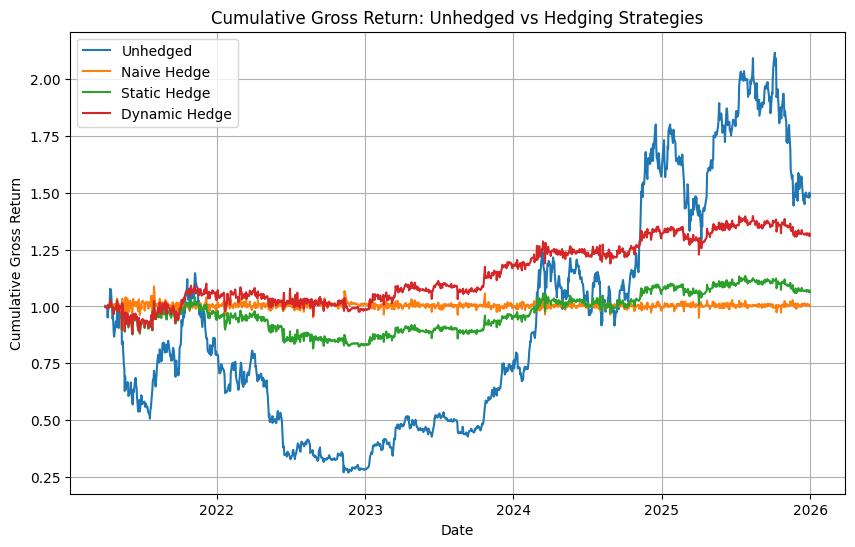

In [38]:
import matplotlib.pyplot as plt

# cumulative gross-return indices
res["cum_unhedged"] = np.exp(res["r_s"].cumsum())
res["cum_naive"] = np.exp(res["r_p_naive"].cumsum())
res["cum_static"] = np.exp(res["r_p_static"].cumsum())
res["cum_dynamic"] = np.exp(res["r_p_dynamic"].cumsum())

# plot
plt.figure(figsize=(10, 6))
plt.plot(res.index, res["cum_unhedged"], label="Unhedged")
plt.plot(res.index, res["cum_naive"], label="Naive Hedge")
plt.plot(res.index, res["cum_static"], label="Static Hedge")
plt.plot(res.index, res["cum_dynamic"], label="Dynamic Hedge")

plt.title("Cumulative Gross Return: Unhedged vs Hedging Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Gross Return")
plt.legend()
plt.grid(True)
plt.show()

The graph shows that the unhedged BTC position has the highest cumulative return in the late bull-market period, but it also has by far the largest volatility and drawdowns. The naive hedge stays almost flat around 1, meaning it nearly neutralizes BTC price exposure. The static and dynamic hedges both reduce volatility substantially while preserving some upside, with the dynamic hedge showing better cumulative performance than the static hedge on this sample path, although the static hedge had slightly better variance reduction overall.

> **Interpretation.** Whether hedging makes sense depends mainly on the investor’s objective.  
> If the goal is **wealth preservation**, hedging can be useful because it reduces the volatility and downside risk of a Bitcoin position.  
> If the goal is **capital growth**, an investor may choose not to hedge, because hedging also gives up part of Bitcoin’s upside.  
> In that case, the main concern is often **position sizing** and **avoiding excessive leverage**, since Bitcoin is already highly volatile.